In [5]:
# Import library
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp

# ------------------------------
# 1. Load Data
# ------------------------------
df = pd.read_csv("karakteristik_arketipe_scaled_back.csv")
df.head()

,Archetype,Avg_Game_Orig,Avg_Playtime_Orig,Avg_Achievement_Orig,Dominant_Topic,Top_3_Genre
0,archetype_1_weight,226.58,25.61,2456.17,4,"['9', '17', '13']"
1,archetype_2_weight,231.29,35.03,2607.86,3,"['1', '2', '13']"
2,archetype_3_weight,247.43,29.85,3560.24,1,"['1', '9', '2']"
3,archetype_4_weight,386.58,26.44,3811.92,4,"['9', '1', '17']"
4,archetype_5_weight,211.29,38.52,2285.71,2,"['1', '2', '9']"


In [6]:
df['Archetype'] = df['Archetype'].astype('category')

In [9]:
# Pastikan hanya angka kategori
df['Archetype'] = df['Archetype'].astype(str)  # pastikan string
df['Archetype'] = df['Archetype'].str.extract('(\d+)')  # ambil hanya angka
df['Archetype'] = df['Archetype'].astype(int).astype('category')



===== Uji Avg_Game_Orig =====
Uji Kruskal-Wallis: H = 4.0 p = 0.406


/var/folders/kh/7d1scz1n2f7gnm2sy2q4rgs00000gn/T/ipykernel_46928/432671343.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group[feature].values for name, group in df.groupby("Archetype")]
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/scipy/stats/_morestats.py:3189: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom


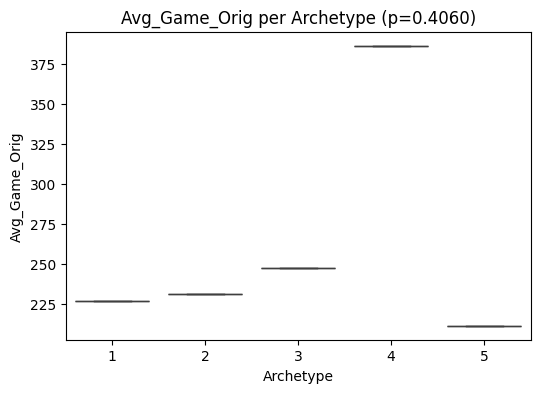


===== Uji Avg_Playtime_Orig =====
Uji Kruskal-Wallis: H = 4.0 p = 0.406


/var/folders/kh/7d1scz1n2f7gnm2sy2q4rgs00000gn/T/ipykernel_46928/432671343.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group[feature].values for name, group in df.groupby("Archetype")]
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/scipy/stats/_morestats.py:3189: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom


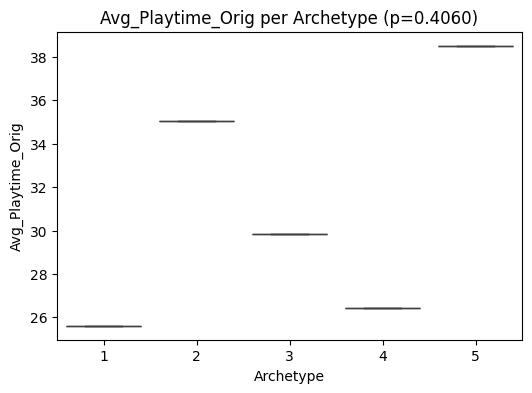


===== Uji Avg_Achievement_Orig =====
Uji Kruskal-Wallis: H = 4.0 p = 0.406


/var/folders/kh/7d1scz1n2f7gnm2sy2q4rgs00000gn/T/ipykernel_46928/432671343.py:6: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  groups = [group[feature].values for name, group in df.groupby("Archetype")]
/Users/divaoncom/Library/Python/3.10/lib/python/site-packages/scipy/stats/_morestats.py:3189: RuntimeWarning: invalid value encountered in scalar divide
  W = numer / denom


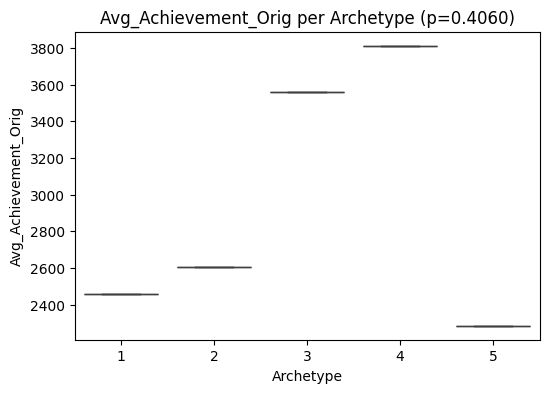

In [10]:
# Daftar fitur numerik
numeric_features = ["Avg_Game_Orig", "Avg_Playtime_Orig", "Avg_Achievement_Orig"]

for feature in numeric_features:
    print(f"\n===== Uji {feature} =====")
    groups = [group[feature].values for name, group in df.groupby("Archetype")]

    # Uji normalitas (Shapiro-Wilk) dan homogenitas varians (Levene)
    normality = [stats.shapiro(g)[1] if len(g) >= 3 else np.nan for g in groups]
    levene_p = stats.levene(*groups)[1]

    if all(p > 0.05 or np.isnan(p) for p in normality) and levene_p > 0.05:
        # ANOVA
        fstat, pval = stats.f_oneway(*groups)
        print("Uji ANOVA: F =", round(fstat,3), "p =", round(pval,4))

        if pval < 0.05:
            tukey = pairwise_tukeyhsd(endog=df[feature],
                                      groups=df['Archetype'],
                                      alpha=0.05)
            print(tukey.summary())
    else:
        # Kruskal-Wallis
        hstat, pval = stats.kruskal(*groups)
        print("Uji Kruskal-Wallis: H =", round(hstat,3), "p =", round(pval,4))

        if pval < 0.05:
            dunn = sp.posthoc_dunn(df, val_col=feature, group_col="Archetype", p_adjust="bonferroni")
            print("Post-hoc Dunn:\n", dunn)

    # Visualisasi Boxplot
    plt.figure(figsize=(6,4))
    sns.boxplot(x="Archetype", y=feature, data=df)
    plt.title(f"{feature} per Archetype (p={pval:.4f})")
    plt.show()



===== Uji Dominant_Topic =====
Chi-Square = 15.0 df = 12 p = 0.2414


Archetype,archetype_1_weight,archetype_2_weight,archetype_3_weight,archetype_4_weight,archetype_5_weight
Dominant_Topic,,,,,
1,0,0,1,0,0
2,0,0,0,0,1
3,0,1,0,0,0
4,1,0,0,1,0


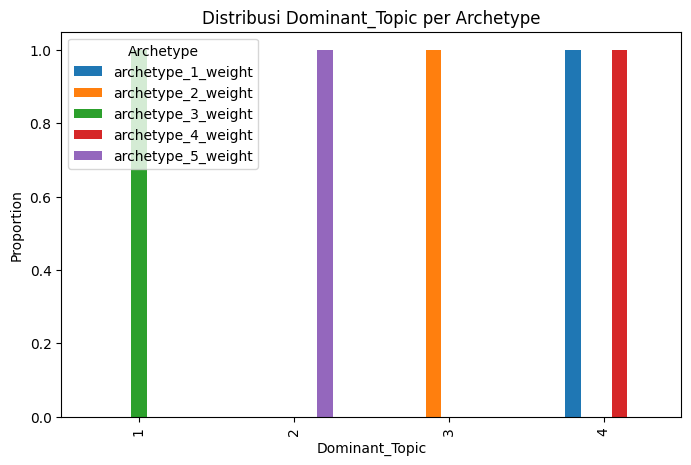


===== Uji Top_3_Genre =====
Chi-Square = 20.0 df = 16 p = 0.2202


Archetype,archetype_1_weight,archetype_2_weight,archetype_3_weight,archetype_4_weight,archetype_5_weight
Top_3_Genre,,,,,
"['1', '2', '13']",0,1,0,0,0
"['1', '2', '9']",0,0,0,0,1
"['1', '9', '2']",0,0,1,0,0
"['9', '1', '17']",0,0,0,1,0
"['9', '17', '13']",1,0,0,0,0


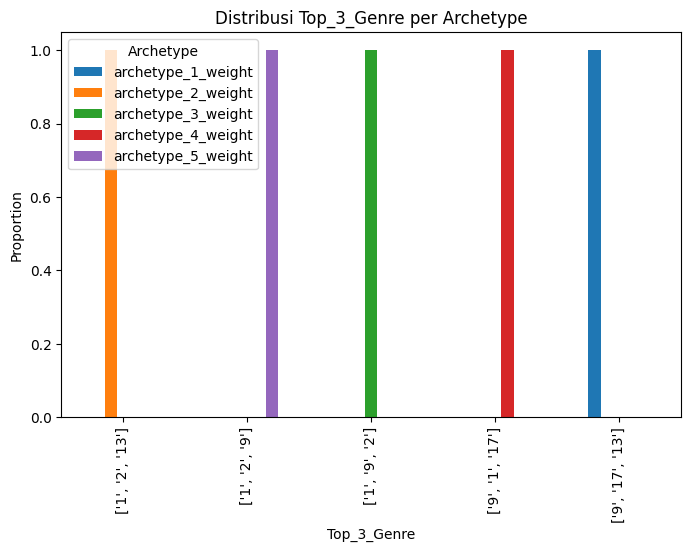

In [8]:
categorical_features = ["Dominant_Topic", "Top_3_Genre"]

for feature in categorical_features:
    print(f"\n===== Uji {feature} =====")
    crosstab = pd.crosstab(df[feature], df["Archetype"])
    chi2, pval, dof, expected = stats.chi2_contingency(crosstab)
    print("Chi-Square =", round(chi2,3), "df =", dof, "p =", round(pval,4))
    display(crosstab)

    # Visualisasi distribusi kategori
    crosstab_norm = crosstab.div(crosstab.sum(axis=0), axis=1)
    crosstab_norm.plot(kind="bar", figsize=(8,5))
    plt.title(f"Distribusi {feature} per Archetype")
    plt.ylabel("Proportion")
    plt.show()


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import silhouette_score

# === 1. Load data ===
# ganti path sesuai file kamu
df = pd.read_csv("karakteristik_arketipe_scaled_back.csv")

# === 2. Ambil fitur numerik & label ===
features = df[["Avg_Game_Orig", "Avg_Playtime_Orig", "Avg_Achievement_Orig"]].values
labels = df["Archetype"].values

# === 3. Hitung silhouette asli ===
silhouette_real = silhouette_score(features, labels)

# === 4. Permutation test ===
n_perm = 1000  # jumlah permutasi
silhouette_perm = np.zeros(n_perm)

for i in range(n_perm):
    shuffled = np.random.permutation(labels)
    sil = silhouette_score(features, shuffled)
    silhouette_perm[i] = sil

# === 5. Hitung p-value ===
p_value = np.mean(silhouette_perm >= silhouette_real)

print(f"Silhouette Asli: {silhouette_real:.3f}")
print(f"P-value Permutasi: {p_value:.4f}")

# === 6. Visualisasi distribusi ===
plt.figure(figsize=(8,5))
plt.hist(silhouette_perm, bins=30, alpha=0.7, color="gray", edgecolor="black")
plt.axvline(silhouette_real, color="red", linestyle="--", linewidth=2,
            label=f"Silhouette Asli = {silhouette_real:.3f}")
plt.xlabel("Silhouette Score (Hasil Permutasi)")
plt.ylabel("Frekuensi")
plt.title(f"Permutation Test Signifikansi Cluster\nP-value = {p_value:.4f}")
plt.legend()
plt.show()


ValueError: Number of labels is 5. Valid values are 2 to n_samples - 1 (inclusive)

In [12]:
df["Archetype"].value_counts()

Archetype
archetype_1_weight    1
archetype_2_weight    1
archetype_3_weight    1
archetype_4_weight    1
archetype_5_weight    1
Name: count, dtype: int64

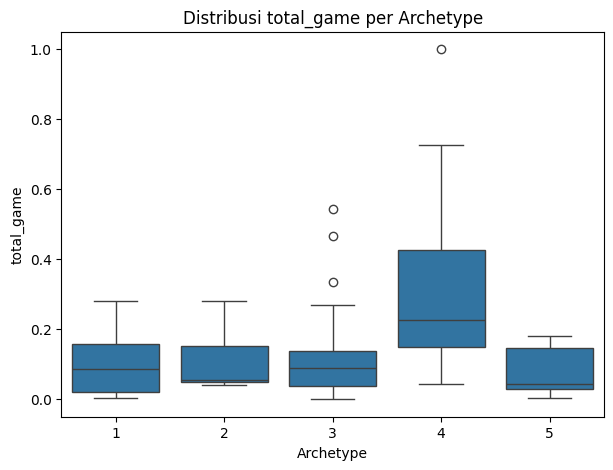

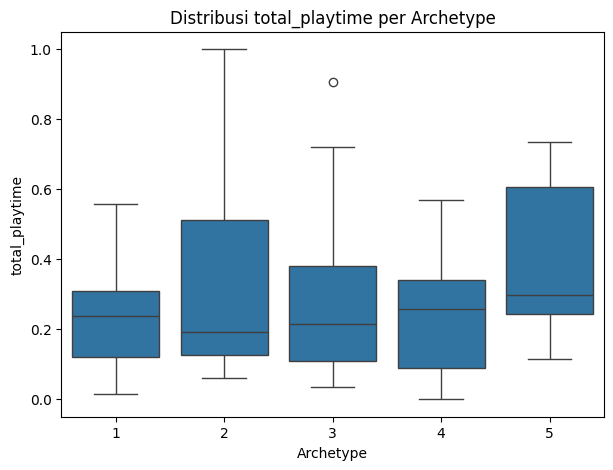

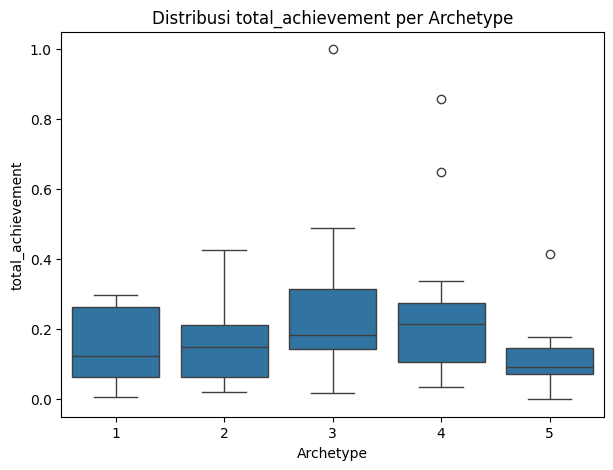


=== total_game ===
Uji: Kruskal-Wallis, p-value: 0.0241, Effect size: None
Post-hoc:
           1        2         3         4         5
1  1.000000  1.00000  1.000000  0.067308  1.000000
2  1.000000  1.00000  1.000000  0.364840  1.000000
3  1.000000  1.00000  1.000000  0.054458  1.000000
4  0.067308  0.36484  0.054458  1.000000  0.086666
5  1.000000  1.00000  1.000000  0.086666  1.000000

=== total_playtime ===
Uji: Kruskal-Wallis, p-value: 0.6474, Effect size: None

=== total_achievement ===
Uji: Kruskal-Wallis, p-value: 0.3081, Effect size: None

=== dominant_topic ===
Chi-Square = 167.888 df = 12 p = 0.0
Residual:
 dominant_topic         1         2         3         4
Archetype                                             
1              -2.066685 -0.491632 -1.193201  2.922996
2              -1.578457 -0.974245  6.769823 -1.651912
3               4.947179 -1.687441 -1.578457 -2.861196
4              -2.066685 -1.275586 -1.193201  3.385347
5              -1.578457  6.210809 -0.9113

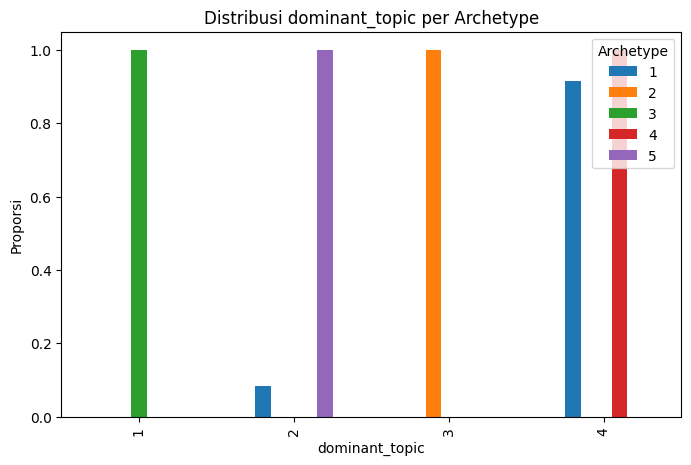


=== top_1_genre ===
Chi-Square = 52.158 df = 8 p = 0.0
Residual:
 top_1_genre        1         9         17
Archetype                                
1           -2.668079  2.612457  1.966456
2            1.397334 -1.501412 -0.770208
3            2.420254 -2.600521 -1.334039
4           -2.293277  2.612457  0.974824
5            0.906604 -0.835372 -0.770208


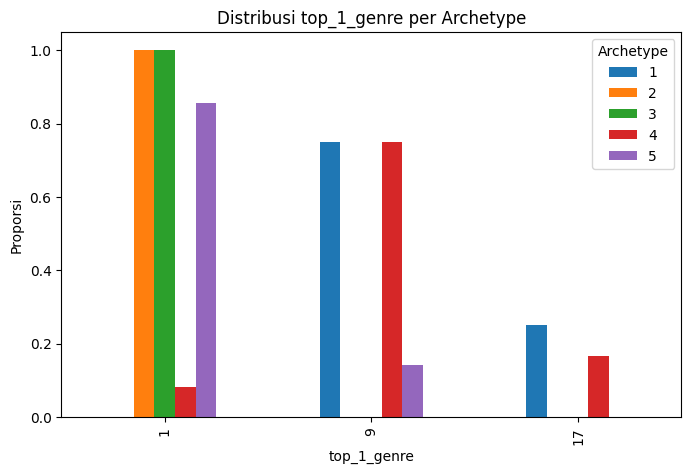


=== top_2_genre ===
Chi-Square = 44.303 df = 16 p = 0.0002
Residual:
 top_2_genre        1         2         9         13        17
Archetype                                                    
1           -0.491632 -1.193385 -0.023769  2.424058  1.076275
2           -0.974245  0.840647 -1.089239  0.762705  0.052192
3           -1.687441  2.078555  0.233581 -1.193201 -1.687441
4            3.428136 -2.428643  0.677420 -0.901975  1.076275
5            0.052192  0.301537 -0.171166 -0.688895  0.052192


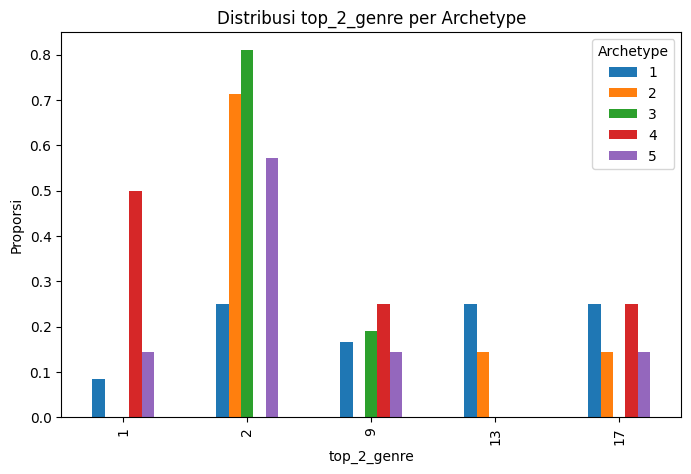


=== top_3_genre ===
Chi-Square = 70.322 df = 20 p = 0.0
Residual:
 top_3_genre        1         2         9         13        15        17
Archetype                                                              
1           -1.008439 -0.724959 -2.162861  2.780989  0.499057  1.860229
2           -0.770208 -0.171166  0.164165  1.664979 -0.596601 -0.974245
3           -1.334039 -0.296468  3.080376 -1.886617 -0.065609 -1.687441
4            3.949719  0.677420 -2.162861 -1.426148 -0.781133  1.860229
5           -0.770208  0.746906  0.164165 -0.171166  1.079563 -0.974245


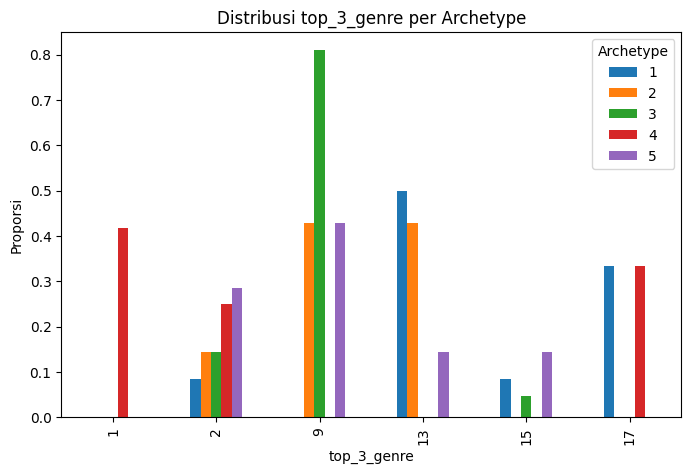

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import scikit_posthocs as sp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.api as sm
import statsmodels.formula.api as smf

# === 1. Load Data ===
df = pd.read_csv("archetypal_segments_elbowK_top3.csv")

# === 2. Tentukan Archetype berdasarkan bobot tertinggi ===
df["Archetype"] = df[["archetype_1_weight","archetype_2_weight",
                      "archetype_3_weight","archetype_4_weight","archetype_5_weight"]].idxmax(axis=1)
df["Archetype"] = df["Archetype"].str.extract("(\d+)").astype(int)

# ---------------------------------------------------------
# A) Uji Atribut Numerik
# ---------------------------------------------------------

numeric_features = ["total_game","total_playtime","total_achievement"]

results_numeric = []

for feature in numeric_features:
    groups = [g[feature].values for _, g in df.groupby("Archetype")]

    # Uji normalitas Shapiro-Wilk
    normality = [stats.shapiro(g)[1] if len(g)>=3 else np.nan for g in groups]
    # Uji homogenitas varians Levene
    levene_p = stats.levene(*groups)[1]

    # Pilih ANOVA atau Kruskal-Wallis
    if all(p > 0.05 or np.isnan(p) for p in normality) and levene_p > 0.05:
        # ANOVA
        fstat, pval = stats.f_oneway(*groups)
        eta_sq = fstat * (len(df) - len(groups)) / (fstat * (len(df) - len(groups)) + (len(df) - len(groups)))
        posthoc = None
        if pval < 0.05:
            tukey = pairwise_tukeyhsd(endog=df[feature], groups=df["Archetype"], alpha=0.05)
            posthoc = tukey.summary()
        results_numeric.append((feature, "ANOVA", pval, eta_sq, posthoc))
    else:
        # Kruskal-Wallis
        hstat, pval = stats.kruskal(*groups)
        # Cliff's delta: pairwise effect size (hanya tampil jika signifikan)
        posthoc = None
        if pval < 0.05:
            dunn = sp.posthoc_dunn(df, val_col=feature, group_col="Archetype", p_adjust="bonferroni")
            posthoc = dunn
        results_numeric.append((feature, "Kruskal-Wallis", pval, None, posthoc))

    # Visualisasi boxplot
    plt.figure(figsize=(7,5))
    sns.boxplot(x="Archetype", y=feature, data=df)
    plt.title(f"Distribusi {feature} per Archetype")
    plt.show()

# Ringkasan hasil numerik
for res in results_numeric:
    feature, test, pval, effect, posthoc = res
    print(f"\n=== {feature} ===")
    print(f"Uji: {test}, p-value: {pval:.4f}, Effect size: {effect}")
    if posthoc is not None:
        print("Post-hoc:\n", posthoc)


# ---------------------------------------------------------
# B) Uji Atribut Kategorikal
# ---------------------------------------------------------

categorical_features = ["dominant_topic","top_1_genre","top_2_genre","top_3_genre"]

for feature in categorical_features:
    contingency = pd.crosstab(df["Archetype"], df[feature])
    chi2, p, dof, expected = stats.chi2_contingency(contingency)

    print(f"\n=== {feature} ===")
    print("Chi-Square =", round(chi2,3), "df =", dof, "p =", round(p,4))

    if p < 0.05:
        # Analisis residual standar
        residuals = (contingency - expected) / np.sqrt(expected)
        print("Residual:\n", residuals)

    # Visualisasi distribusi
    contingency_norm = contingency.div(contingency.sum(axis=1), axis=0)
    contingency_norm.T.plot(kind="bar", figsize=(8,5))
    plt.title(f"Distribusi {feature} per Archetype")
    plt.ylabel("Proporsi")
    plt.show()
